# Do Higher Video Game Prices Reflect Quality or Sales?

An exploratory data analysis examining how video game prices relate to critic scores, user ratings, and global sales.

## Overview
Video game prices have increased over time, raising questions about whether higher prices reflect better quality or improved sales outcomes.





## Dataset
- Video game features dataset (Metacritic, release date, etc.)
- Pricing dataset

## Research Questions
1. How have video game prices changed over time?
2. Do higher-priced games receive better critic and user scores?
3. Is there a relationship between price and global sales?

---

## Data Source & Setup

Place the dataset files in a `data/` folder in the project directory before running this notebook.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import statsmodels.api as sm


In [ ]:
vgsale = pd.read_csv('data/vgsales.csv')
vgprice = pd.read_csv('data/game_prices.csv')

## Data Wrangling

In [2]:
# Merge into one dataset
vgprice= vgprice.rename(columns={'ResponseName': 'Name'})
vgdata = pd.merge(vgprice,vgsale, on= 'Name', how = 'inner')

In [3]:
# Remove duplicate games based on name
vgdata = vgdata.drop_duplicates(subset=['Name'], keep='first')

In [4]:
# Edit release date format
vgdata['ReleaseDate'] = pd.to_datetime(vgdata['ReleaseDate'], errors='coerce')
vgdata['ReleaseYear'] = vgdata['ReleaseDate'].dt.year

,Name,ReleaseDate,Metacritic,RecommendationCount,IsFree,GenreIsNonGame,GenreIsIndie,GenreIsAction,GenreIsAdventure,GenreIsCasual,...,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,ReleaseYear
0,Counter-Strike,2000-11-01,88,68991,False,False,False,True,False,False,...,0.00,0.04,1.11,74.0,38.0,7.6,51.0,Valve Software,M,2000.0
1,Half-Life,1998-11-08,96,12486,False,False,False,True,False,False,...,0.09,0.00,4.12,96.0,24.0,9.1,3161.0,Valve Software,M,1998.0
3,Half-Life 2,2004-11-16,96,35792,False,False,False,True,False,False,...,0.08,0.00,2.37,96.0,81.0,9.1,8665.0,Valve Software,M,2004.0
5,Counter-Strike: Source,2004-11-01,88,53931,False,False,False,True,False,False,...,0.00,0.02,0.08,88.0,9.0,8.9,9851.0,Valve Software,M,2004.0
6,Left 4 Dead,2008-11-17,89,9980,False,False,False,True,False,False,...,0.05,0.30,3.51,89.0,67.0,7.9,1309.0,Certain Affinity,M,2008.0


In [5]:
# Handle missing values
cols_to_fix = ['Metacritic', 'Global_Sales', 'User_Score','PriceInitial']
vgdata[cols_to_fix] = vgdata[cols_to_fix].apply(pd.to_numeric, errors='coerce')

In [6]:
# Filter for relevant columns
vgdata = vgdata.loc[:,['Name', 'Metacritic','ReleaseDate','Global_Sales','User_Score','Developer','PriceInitial']]

,Name,Metacritic,ReleaseDate,Global_Sales,User_Score,Developer,PriceInitial
0,Counter-Strike,88,2000-11-01,1.11,7.6,Valve Software,9.99
1,Half-Life,96,1998-11-08,4.12,9.1,Valve Software,9.99
3,Half-Life 2,96,2004-11-16,2.37,9.1,Valve Software,9.99
5,Counter-Strike: Source,88,2004-11-01,0.08,8.9,Valve Software,19.99
6,Left 4 Dead,89,2008-11-17,3.51,7.9,Certain Affinity,19.99


---

# Analysis

## Research Question 1: How have game prices changed over time?


### Visualization
This visualization shows how video game prices have changed over time.

<Axes: title={'center': 'Price trends (1998-2017)'}, xlabel='Game Release Year', ylabel='Game inital Release'>

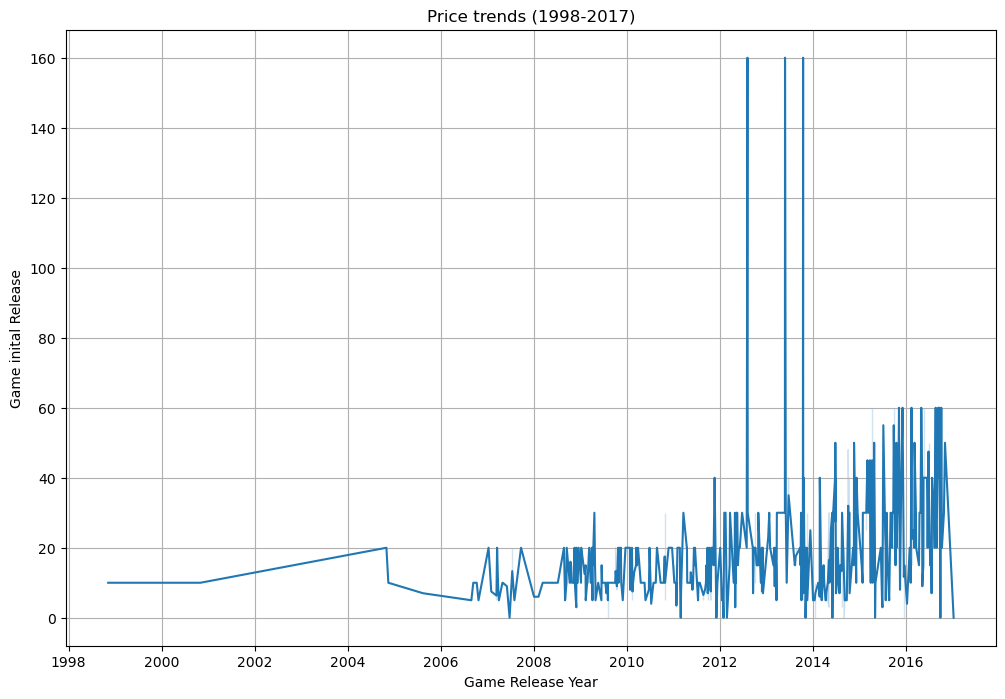

In [7]:
# Your visualization code for RQ1
plt.figure(figsize=(12,8))
plt.title('Price trends (1998-2017)')
plt.xlabel('Game Release Year')
plt.ylabel('Game inital Release')
plt.grid(True)
sns.lineplot(data=vgdata, x='ReleaseDate', y='PriceInitial')

The visualization shows a clear upward trend in video game prices over time, with a noticeable increase after 2010.

This suggests that modern games are released at higher initial price points compared to earlier decades, reflecting changes in industry pricing standards.

This reflects a broader industry shift toward standardized higher launch prices for modern games.

---

## Research Question 2: Does price influence the relationship between critic and user scores? 

To compare price groups, I separated games into low- and high-price categories and analyzed how critic scores relate to user scores within each group.


### Visualization

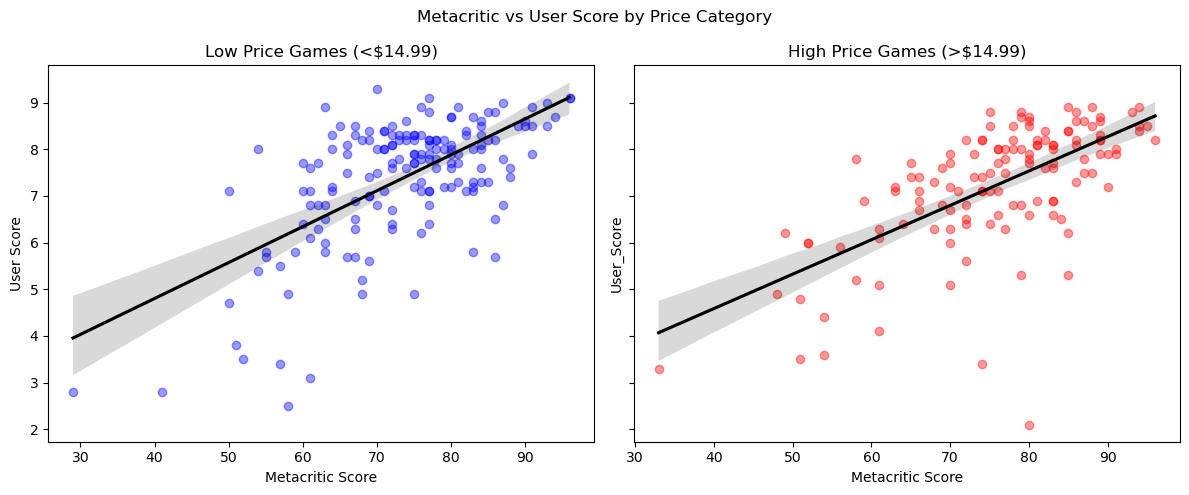

In [9]:

# separates the price into two categories and filter for those without scores
vgdata = vgdata[vgdata['Metacritic'] > 0]
low = vgdata[vgdata['PriceInitial'] <= vgdata['PriceInitial'].median()]
high = vgdata[vgdata['PriceInitial'] > vgdata['PriceInitial'].median()]

# Create price category column
vgdata['PriceCategory'] = vgdata['PriceInitial'].apply(
    lambda x: 'Low' if x <= vgdata['PriceInitial'].median() else 'High'
)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# DataFrames for regplots
low_df = vgdata[vgdata['PriceCategory'] == 'Low']
high_df = vgdata[vgdata['PriceCategory'] == 'High']

# LOW PRICE subplot
sns.regplot(
    data=low_df,
    x='Metacritic',
    y='User_Score',
    scatter_kws={'alpha': 0.4, 'color': 'blue'},
    line_kws={'color': 'black'},
    ax=axs[0]
)
axs[0].set_title('Low Price Games (<$14.99)')
axs[0].set_xlabel('Metacritic Score')
axs[0].set_ylabel('User Score')

# HIGH PRICE subplot
sns.regplot(
    data=high_df,
    x='Metacritic',
    y='User_Score',
    scatter_kws={'alpha': 0.4, 'color': 'red'},
    line_kws={'color': 'black'},
    ax=axs[1]
)
axs[1].set_title('High Price Games (>$14.99)')
axs[1].set_xlabel('Metacritic Score')

plt.suptitle('Metacritic vs User Score by Price Category')
plt.tight_layout()
plt.show()


In [10]:
# Clean up N/A values
low_clean = low_df.dropna(subset=['User_Score'])
high_clean = high_df.dropna(subset=['User_Score'])

# Linear regression model
low_stats = linregress(low_clean['Metacritic'], low_clean['User_Score'])
high_stats = linregress(high_clean['Metacritic'], high_clean['User_Score'])

print(f"LOW PRICE:  Slope={low_stats.slope:.3f}, R-squared={low_stats.rvalue**2:.3f}")
print(f"HIGH PRICE: Slope={high_stats.slope:.3f}, R-squared={high_stats.rvalue**2:.3f}")

LOW PRICE:  Slope=0.077, R-squared=0.396
HIGH PRICE: Slope=0.074, R-squared=0.411


## Analysis

The relationship between critic scores and user scores is positive for both low- and high-priced games, with nearly identical slopes.
While the high-price group has a slightly higher R-squared value, indicating a marginally better model fit, the difference is minimal.
Overall, price does not meaningfully change the relationship between critic and user scores.

### Model
To determine the effect of the price on the relationship between user score and Metacritic score, I  fit a statsmodel prediction.

In [12]:
import statsmodels.api as sm

vgdata['PriceCategory'] = pd.Categorical(vgdata['PriceCategory'], categories=['Low', 'High'])

price_dummies = pd.get_dummies(vgdata['PriceCategory'], drop_first=True, dtype=int)

X = sm.add_constant(pd.concat([vgdata[['Metacritic']], price_dummies], axis=1))

X['Interaction'] = X['Metacritic'] * X['High']

y = vgdata['User_Score']
model = sm.OLS(y, X, missing='drop').fit()

# Display results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             User_Score   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     66.05
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.26e-32
Time:                        09:53:21   Log-Likelihood:                -427.56
No. Observations:                 296   AIC:                             863.1
Df Residuals:                     292   BIC:                             877.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.7235      0.547      3.150      

### Regression Results 
An OLS regression model was used to test whether price level influences the relationship between critic scores and user scores.
The regression results show that Metacritic score is a strong and statistically significant predictor of user score (p < 0.001), indicating a positive relationship between critic and user ratings.

The price group variable is not statistically significant, suggesting no meaningful difference in baseline user scores between high- and low-priced games.

Most importantly, the interaction term between price and Metacritic score is not statistically significant (p > 0.05), indicating that price does not meaningfully change the relationship between critic and user scores.

Overall, the relationship between critic and user ratings is consistent across price levels.

This directly answers the research question by showing that price does not influence how critic and user scores relate to each other.

---

## Research Question 3:
### Is there a relationship between price and global sales?

## Visualization

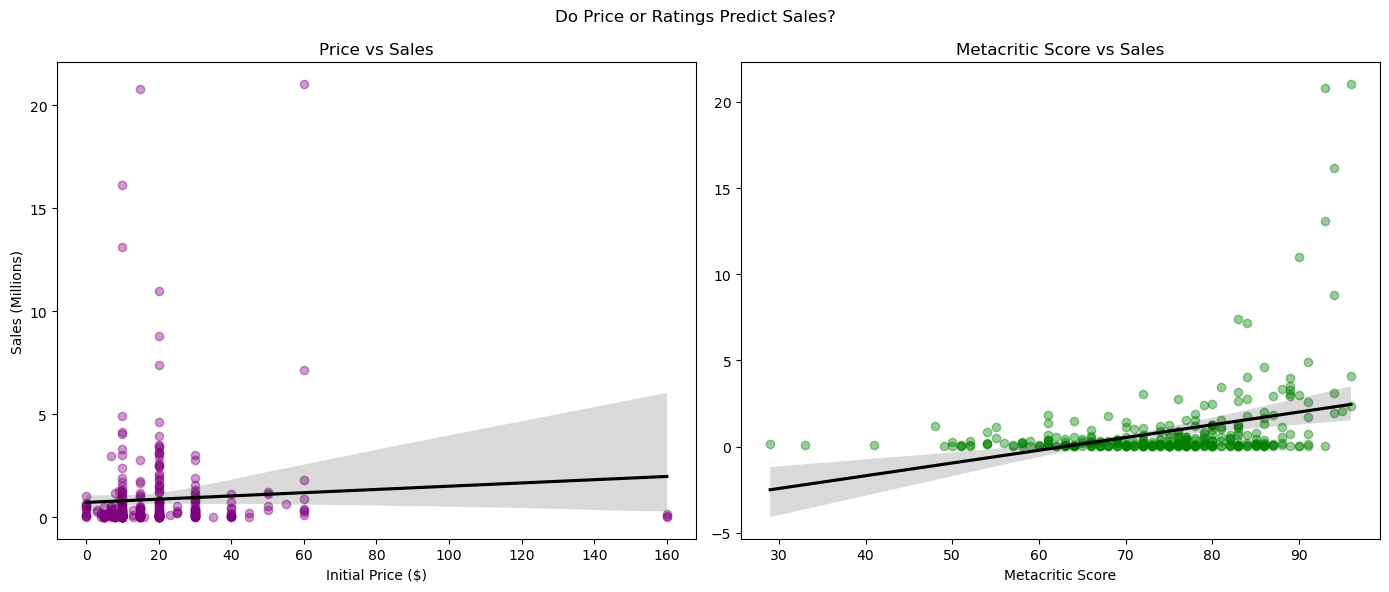

In [13]:
# Clean data for the variables we need
df = vgdata.dropna(subset=['PriceInitial', 'Global_Sales', 'Metacritic'])

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

#Price vs Sales 
sns.regplot(
    data=df,
    x='PriceInitial',
    y='Global_Sales',
    scatter_kws={'alpha': 0.4, 'color': 'purple'},
    line_kws={'color': 'black'},
    ax=axs[0]
)
axs[0].set_title("Price vs Sales")
axs[0].set_xlabel("Initial Price ($)")
axs[0].set_ylabel("Sales (Millions)")

# Metacritic vs Sales
sns.regplot(
    data=df,
    x='Metacritic',
    y='Global_Sales',
    scatter_kws={'alpha': 0.4, 'color': 'green'},
    line_kws={'color': 'black'},
    ax=axs[1]
)
axs[1].set_title("Metacritic Score vs Sales")
axs[1].set_xlabel("Metacritic Score")
axs[1].set_ylabel("")

plt.suptitle("Do Price or Ratings Predict Sales?")
plt.tight_layout()
plt.show()



To determine the relationship between price and sales, I  fit a statsmodel prediction.


# Models

In [14]:
#Price vs vs Global Sales prediction model
pVs = vgdata.dropna(subset=['PriceInitial', 'Global_Sales'])

X = sm.add_constant(df['PriceInitial'])
y = df['Global_Sales']

model_price_sales = sm.OLS(y, X).fit()
print('MODEL 1: PRICE PREDICTING SALES')
print(model_price_sales.summary())


MODEL 1: PRICE PREDICTING SALES
                            OLS Regression Results                            
Dep. Variable:           Global_Sales   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.287
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.257
Time:                        09:53:21   Log-Likelihood:                -729.17
No. Observations:                 324   AIC:                             1462.
Df Residuals:                     322   BIC:                             1470.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           

### Model 1 Regression Results 
The regression results show that price is not a statistically significant predictor of global sales (p = 0.257).
Additionally, the model explains almost none of the variation in sales (R² = 0.004), indicating that price has little to no predictive power for sales performance.

To determine the relationship between ratings and sales, I  fit a statsmodel prediction.

In [15]:
# Ratings vs Global Sales prediction model
rVs = vgdata[(vgdata['Metacritic'] > 0) & (vgdata['User_Score'] > 0)].copy()

X2 = sm.add_constant(rVs[['Metacritic', 'User_Score']])
y2 = rVs['Global_Sales']
model_ratings_sales = sm.OLS(y2, X2).fit()
print('MODEL 2: RATINGS PREDICTING SALES')
print(model_ratings_sales.summary())

MODEL 2: RATINGS PREDICTING SALES
                            OLS Regression Results                            
Dep. Variable:           Global_Sales   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     23.06
Date:                Sun, 03 May 2026   Prob (F-statistic):           5.00e-10
Time:                        09:53:21   Log-Likelihood:                -657.11
No. Observations:                 296   AIC:                             1320.
Df Residuals:                     293   BIC:                             1331.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5

### Model 2 Regression Results 
Metacritic score is a positive and statistically significant predictor of global sales (p < 0.001), indicating that higher-rated games tend to achieve greater sales.

User score is not statistically significant (p = 0.242), suggesting that player ratings are not a strong predictor of sales in this dataset.

Compared to price, critic scores provide substantially more explanatory power for predicting sales, although overall predictive strength remains moderate.

The very low explanatory power of the price model suggests that factors beyond price likely play a larger role in determining sales.

---

# Limitations & Reflection

This project has several limitations that should be considered when interpreting the results. First, my dataset includes only video games that appeared in both datasets I merged. This means that any games missing from either source were excluded, potentially biasing the sample toward more popular titles. Sales data is highly skewed, which may affect the reliability of linear regression assumptions. As a result, the findings do not fully represent the entire video game market.

Second, the variables available in the dataset do not capture many important factors that likely influence both price and sales. For example, production budget, marketing spending, franchise popularity, release timing, and platform exclusivity are all known to affect game performance but were not included in the analysis. Without these variables, the models may underestimate or misattribute the true predictors of sales.

Finally, the results are correlational and cannot determine causation. Even though ratings were stronger predictors of sales than price, this does not necessarily mean that higher ratings cause higher sales. It is also possible that well‑funded or highly anticipated games receive more attention, leading to both higher ratings and higher sales. Future research could incorporate additional datasets, industry reports, or widespread  data to  understand the factors that drive video game pricing and sales.


---
## Conclusion

This analysis finds that while video game prices have increased over time, higher prices do not lead to higher sales.

Critic scores are a significant predictor of both user ratings and sales, while user scores and price are not strong predictors of commercial success.

These findings suggest that consumer purchasing decisions are more closely aligned with critical reception than with price.

Overall, price appears to reflect market trends rather than quality or sales performance, while critic evaluations provide more meaningful insight into a game's success.